In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import os
import scipy.io
import numpy as np
from PIL import Image


import math

from sklearn.linear_model import OrthogonalMatchingPursuit

import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.utils import shuffle


# response, gt
# for response, data is loaded in mat['N']. np[512, 612]
# for gt, data is loaded in mat['temp_patch'], dtype=uint16, need to turn unit16 -> float() [449, 449]

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
def normalize_matrix(matrix):
    # Convert the matrix to a numpy array if it isn't already
    matrix = np.array(matrix)

    # Find the minimum and maximum values in the matrix
    min_val = np.min(matrix)
    max_val = np.max(matrix)

    # Normalize the matrix to range [0, 1]
    normalized_matrix = (matrix - min_val) / (max_val - min_val)

    return normalized_matrix


def down_sample_matrix(input_matrix, downfactor):
    # Get the dimensions of the input matrix
    rows, cols = input_matrix.shape

    # Calculate the dimensions of the downsampled matrix
    new_rows = rows // downfactor
    new_cols = cols // downfactor

    # Initialize the downsampled matrix
    down_matrix = np.zeros((new_rows, new_cols))

    for i in range(new_rows):
        for j in range(new_cols):
            # Define the block from the input matrix to average
            block = input_matrix[i*downfactor:(i+1)*downfactor, j*downfactor:(j+1)*downfactor]
            # Compute the average of the block and assign it to the downsampled matrix
            down_matrix[i, j] = np.mean(block)

    return down_matrix

def split_data(response_list, gt_list, train_ratio=0.97, val_ratio=0.02, test_ratio=0.01):
    assert len(response_list) == len(gt_list), "The two lists must have the same length"

    # Convert to numpy arrays for easier manipulation
    response_array = np.array(response_list)
    gt_array = np.array(gt_list)

    # Shuffle the data
    indices = np.arange(len(response_list))
    np.random.shuffle(indices)
    response_array = response_array[indices]
    gt_array = gt_array[indices]

    # Calculate the number of samples for each set
    total_samples = len(response_list)
    train_end = int(train_ratio * total_samples)
    val_end = train_end + int(val_ratio * total_samples)

    # Split the data
    response_train = response_array[:train_end]
    gt_train = gt_array[:train_end]
    response_val = response_array[train_end:val_end]
    gt_val = gt_array[train_end:val_end]
    response_test = response_array[val_end:]
    gt_test = gt_array[val_end:]

    return (response_train, gt_train), (response_val, gt_val), (response_test, gt_test)


def mat2vec(matrix):
    """
    Turns a matrix into a vector.

    Parameters:
    matrix (array-like): The input matrix.

    Returns:
    np.ndarray: The resulting vector.
    """
    return np.array(matrix).flatten()

def vec2mat(vec, matrix_shape):
    """
    Turns a vector into a matrix with a given shape.

    Parameters:
    vec (array-like): The input vector.
    matrix_shape (tuple): The shape of the desired output matrix (rows, cols).

    Returns:
    np.ndarray: The resulting matrix.
    """
    return np.array(vec).reshape(matrix_shape)


def mask_response_circle(image):

    # Input an image, and return a circle round mask to get the main part in the scope img

    image_np = np.array(image)

    # Define the center and radius of the circle
    height, width = image_np.shape
    center = (width // 2, height // 2)
    radius = min(center)  # Adjust radius as needed

    y, x = np.ogrid[:height, :width]

    # Create a mask
    mask = np.zeros((height, width), dtype=np.uint8)
    dist_from_center = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    mask[dist_from_center <= radius] = 1

    # Apply the mask
    # masked_image = image_np * mask

    # plt.imshow(masked_image, cmap='gray')


    return mask




In [3]:
file_name_response = '/content/drive/MyDrive/JHU Optics/transfer0911/s'
file_name_gt = '/content/drive/MyDrive/JHU Optics/transfer0911/cut2_gt'

response_list = []
gt_list = []

response_down_list = []
gt_down_list = []

response_down_flat_list = []
gt_down_flat_list = []

load_num = 5
downsample_factor_res = 20
downsample_factor_gt = 20

for i in range(load_num):

    response_name = os.path.join(file_name_response + str(i+1) +'_no_bg.mat')
    gt_name = os.path.join(file_name_gt + str(i+1) + '.mat')

    mat_response = scipy.io.loadmat(response_name)
    mat_gt = scipy.io.loadmat(gt_name)

    # Read the response, and using part of it

    mat_response_content = mat_response['bla'].astype(float)
    mat_response_content_part = mat_response_content[:, 500:]


    # Maksed the response

    mask = mask_response_circle(mat_response_content_part)
    mat_response_content_part_masked = mat_response_content_part * mask

    mat_response_content_part_masked[mat_response_content_part_masked < 0] = 0


    # Normalized the masked response & gt

    mat_gt_content = mat_gt['temp_patch'].astype(float)
    mat_gt_content[mat_gt_content < 0] = 0

    mat_response_normalized = normalize_matrix(mat_response_content_part_masked)       # Normalized response mat
    mat_gt_normalized  = normalize_matrix(mat_gt_content)           # Normalized gt mat


    response_list.append(mat_response_normalized)
    gt_list.append(mat_gt_normalized)

    # Down-Sample both

    '''

    mat_response_down = down_sample_matrix(mat_response_normalized, downsample_factor_res)
    mat_gt_down = down_sample_matrix(mat_gt_normalized, downsample_factor_gt)


    mask_down = mask_response_circle(mat_response_down)

    mat_response_down_masked = (mat_response_down + 1e-6) * mask_down

    vec_response_down_masked = mat2vec(mat_response_down_masked)
    vec_response_down_masked_zeroout = vec_response_down_masked[vec_response_down_masked > 0]



    response_down_list.append(mat_response_down)
    gt_down_list.append(mat_gt_down)

    #mask_down = mask_response_circle(mat_response_down)


    #response_down_flat_list.append(vec_response_down_masked_zeroout)
    #gt_down_flat_list.append(mat2vec(mat_gt_down))

    '''


response_set_all = np.array(response_list)  # (load_num, 2048, 2448)
gt_set_all = np.array(gt_list)              # (load_num, 866, 866)

#response_down_list = np.array(response_down_list)
#gt_down_list = np.array(gt_down_list)

#response_down_flat_list = np.array(response_down_flat_list)
#gt_down_flat_list = np.array(gt_down_flat_list)



response_set_all.shape

(5, 2048, 1948)

In [19]:
import numpy as np

def fourdirection_downsample(response, gt, downsample_factor):
    '''
    Downsample an image from four corners: top-left, top-right, bottom-left, bottom-right.

    Parameters:
    - response (np.array): The response image array.
    - gt (np.array): The ground truth image array.
    - downsample_factor (int): The factor by which the image should be downsampled.

    Returns:
    - dict: A dictionary containing four pairs of downsampled response and gt images.
    '''
    def downsample_from_corner(img, start_row, start_col):
        return img[start_row::downsample_factor, start_col::downsample_factor]

    height, width = response.shape[:2]
    images = {}

    # Top-left corner
    images['top_left'] = (
        downsample_from_corner(response, 0, 0),
        downsample_from_corner(gt, 0, 0)
    )

    # Top-right corner
    images['top_right'] = (
        downsample_from_corner(response, 0, width % downsample_factor),
        downsample_from_corner(gt, 0, width % downsample_factor)
    )

    # Bottom-left corner
    images['bottom_left'] = (
        downsample_from_corner(response, height % downsample_factor, 0),
        downsample_from_corner(gt, height % downsample_factor, 0)
    )

    # Bottom-right corner
    images['bottom_right'] = (
        downsample_from_corner(response, height % downsample_factor, width % downsample_factor),
        downsample_from_corner(gt, height % downsample_factor, width % downsample_factor)
    )

    return images


In [22]:
test_down = fourdirection_downsample(response_set_all[0], gt_set_all[0], 10)

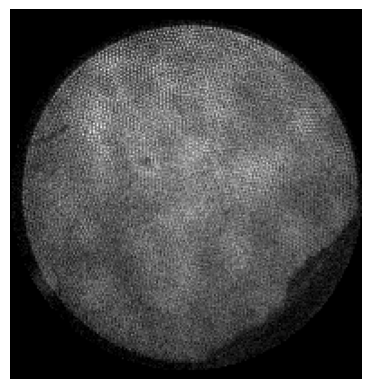

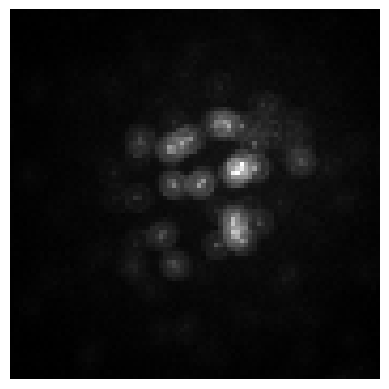

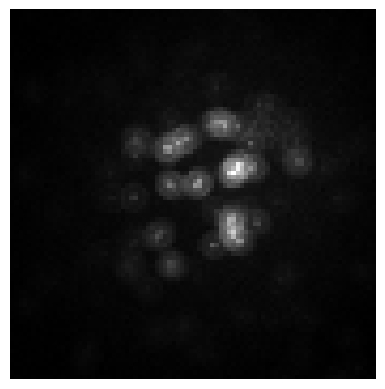

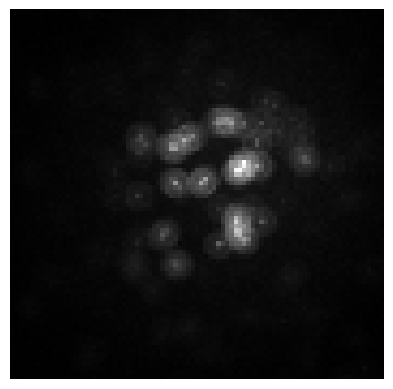

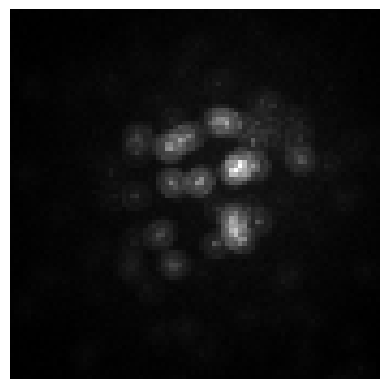

In [23]:
plt.imshow(test_down['top_left'][0], cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(test_down['top_left'][1], cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(test_down['top_right'][1], cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(test_down['bottom_left'][1], cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(test_down['bottom_right'][1], cmap='gray')
plt.axis('off')
plt.show()